# Desafio Extra — Introdução à Inteligência Artificial

## Hotel Booking Demand

**Autor:** Fabiana Nonjah  
**Curso:** Introdução à Inteligência Artificial  
**Projeto:** Análise Exploratória de Dados e Modelo Preditivo  
**Dataset:** Hotel Booking Demand  
**Variável-alvo:** `is_canceled`

### Objetivo

## Realizar uma Análise Exploratória de Dados (AED) e desenvolver um modelo preditivo introdutório de Inteligência Artificial utilizando o dataset público Hotel Booking Demand, buscando identificar padrões de reservas e cancelamentos e avaliar um modelo de classificação para prever a variável `is_canceled`.

In [177]:
# Importação da biblioteca Pandas

import pandas as pd

In [178]:
# Carregamento do Dataset

df = pd.read_csv('/content/hotel_bookings.csv')

### Visualização inicial do Dataset

Visualização das primeiras linhas para verificar se o arquivo Hotel Booking Demand foi carregado corretamente.

In [179]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Dimensões do Dataset

Verificação da quantidade de linhas e colunas presentes no Dataset antes do início do tratamento dos dados.

In [180]:
# Confirmando número de linhas e de colunas no CSV, contendo 119.390 registros em 32 colunas
df.shape

(119390, 32)

### Verificação das Colunas

Identificação das colunas disponíveis no Dataset para compreender as variáveis que serão utilizadas nas etapas de tratamento, análise exploratória e modelagem preditiva.

In [181]:
# Confirmado que existem 32 colunas, quais são e a coluna TARGET (Alvo = is_canceled).
# Confirmando as variáveis úteis para o teste extra, como 'hotel', 'is_canceled', 'lead_time', entre outras.
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

### Verificação da Estrutura e de Valores Nulos

Verificação dos tipos de dados de cada coluna (inteiro, float, objeto/texto...) e da quantidade de valores não nulos presentes no Dataset, como etapa inicial de diagnóstico para o tratamento dos dados.

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Quantificação dos Valores Nulos

### Quantificação dos Valores Nulos

Identificação da quantidade de valores nulos em cada coluna do Dataset para orientar as decisões de tratamento dos dados.

In [183]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


### Verificação de Registros Duplicados

Verificação da existência de registros duplicados no Dataset antes da etapa de tratamento dos dados.

In [184]:
# identificar linhas que são duplicadas

df.duplicated().sum()

np.int64(31994)

### Percentual de Registros Duplicados

Cálculo do percentual de registros duplicados em relação ao total de registros do Dataset.
<p>
df.duplicated().sum() → conta os registros duplicados.<p>
len(df) → informa o total de registros.<p>
* 100 → transforma o resultado em percentual.<p>
:.2f → mostra o percentual com duas casas decimais.

In [185]:
percentual_duplicados = df.duplicated().sum() / len(df) * 100
print(f"Percentual de registros duplicados: {percentual_duplicados:.2f}%")

Percentual de registros duplicados: 26.80%


### Investigação dos Registros Duplicados

Análise dos registros identificados como duplicados para verificar se representam repetições indevidas ou se possuem características que justifiquem sua permanência no Dataset.

In [186]:
# df.duplicated(keep=False) marca todas as ocorrências das linhas duplicadas, inclusive a primeira ocorrência.
# df[...] filtra o DataFrame para mostrar somente essas linhas.
# .head(10) mostra apenas as primeiras 10 ocorrências para análise.

df[df.duplicated(keep=False)].head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
132,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
198,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


### Tratamento de Registros Duplicados

Foram identificados 31.994 registros duplicados, correspondentes a 26,80% do Dataset original. Após a verificação, constatou-se que eram duplicações exatas de registros em todas as colunas. Por isso, os registros duplicados serão removidos no passo a seguir, antes das etapas de análise e modelagem.

In [187]:
# remove as linhas que possuem todos os valores iguais a outra linha.

df = df.drop_duplicates()

### Verificação após o Tratamento de Duplicados

Conferir a quantidade de registros e colunas após a remoção dos registros duplicados.

In [188]:
# Confere o tamanho do Dataset (agora, após remover registros duplicados)

df.shape

(87396, 32)

In [189]:
# Verificar se após limpeza de registros duplicados ainda resta algum duplicado.

df.duplicated().sum()

np.int64(0)

In [190]:
# Verificar se existem valores nulos.

df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [191]:
# Percentual de valores nulos: descobrir qual percentual do dataset cada coluna representa

# df.isnull() → identifica os valores ausentes.
# .sum() → conta quantos existem em cada coluna.
# len(df) → obtém a quantidade de linhas do DataFrame.
# / len(df) * 100 → transforma a quantidade em percentual de valores nulos.


df.isnull().sum() / len(df) * 100

,0
hotel,0.000000
is_canceled,0.000000
lead_time,0.000000
arrival_date_year,0.000000
arrival_date_month,0.000000
arrival_date_week_number,0.000000
arrival_date_day_of_month,0.000000
stays_in_weekend_nights,0.000000
stays_in_week_nights,0.000000
adults,0.000000


### Necessário verificar algumas colunas:

<p> agent: 13,9514% → 12.193 registros.
<p> company: 93,9826% → 82.137 registros.

<p> company precisa atenção especial: quase 94% dos registros são nulos. Preencher esses valores pode introduzir informação que não existe.

<p> agent: apesar de ter 13,95% de ausências, não é uma variável numérica contínua como adr; ela representa um identificador.

<p> children: 0,0046% → só 4 registros.
<p> country: 0,5172% → 452 registros.

In [192]:
# Verificar valores existentes nas colunas 'agent' e 'company' - as problemáticas.
# Aálise a partir das 20 primeiras linhas/registros.

df[['agent', 'company']].head(20)



,agent,company
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,304.0,NaN
4,240.0,NaN
6,NaN,NaN
7,303.0,NaN
8,240.0,NaN
9,15.0,NaN
10,240.0,NaN


### Criação de uma cópia do DataFrame para tratamento

Momento de criar uma cópia do DataFrame original para realizar o tratamento e a preparação dos dados. Dessa forma, o conjunto de dados original será preservado, permitindo comparar os dados antes e depois das etapas de limpeza e preparação.

<p>

In [193]:
# Criar uma cópia independente do DataFrame df e guardar essa cópia na variável df_tratado
# df é DataFrame original, onde está o dataset que foi carregado df = pd.read_csv('/content/hotel_bookings.csv')
# .copy() comando oara criar cópia do original para poder modificar, sem alterar o DataFrame original

df_tratado = df.copy()

In [194]:
# Verificar se a cópia do DataFrame foi criada corretamente. Se tem a mesma quantidade de linhas e colunas:

df_tratado.shape

(87396, 32)

### Tratamento de valores nulos na coluna `children`

A coluna `children` apresenta 4 valores nulos, correspondentes a aproximadamente 0,0046% dos registros. Como se trata de uma variável numérica e a quantidade de valores ausentes é muito pequena, é possível utilizar a mediana da própria coluna para realizar a imputação, preservando os registros do Dataset.

In [195]:
# df_tratado['children'] seleciona a coluna 'children' dentro do DataFrame tratado (cópia do original.
# df_tratado['children'].median() Calcula a mediana dos valores existentes na coluna 'children'.
# Mediana é o valor que fica no meio dos dados quando eles são ordenados. É útil para preencher valores ausentes por ser menos sensível a valores extremos do que a média.
# df_tratado['children'] =  quer dizer que o resultado do tratamento será colocado novamente na coluna 'children'.
# .fillna(...)   .fillna(df_tratado['children'].median()) Encontra os valores NaN e substitui eles pela Mediana. Ou seja, os 4 valores ausentes de 'children' foram preenchidos.


df_tratado['children'] = df_tratado['children'].fillna(df_tratado['children'].median())

In [196]:
# Comprovar que os 4 valores nulos foram realmente tratados.

df_tratado['children'].isnull().sum()

np.int64(0)

A coluna 'children' apresentava 4 valores nulos (0,0046% dos registros). Como a variável é numérica e a quantidade de ausências era muito pequena, os valores foram imputados utilizando a mediana da coluna.

### Próxima etapa:Analisar e tratar a coluna 'country'

<p> A coluna possui:

<p> 452 valores nulos   = 0,517186%

<p> 'country' representa o país de origem do hóspede. Primeiro é necessário verificar quais valores existem na coluna.

### Tratamento de valores nulos na coluna `country`

A coluna `country` apresenta 452 valores nulos, correspondentes a aproximadamente 0,52% dos registros.

<p>Como `country` é uma variável categórica que representa o país de origem do hóspede, os valores ausentes não serão substituídos por um país específico.

<p>A estratégia utilizada será preencher com a categoria Unknown (desconhecido), para representar os registros em que o país de origem não foi informado.

<p> O objetivo é preservar os dados sem definir uma informação que não consta no Dataset.

In [197]:
# Exibir os 15 países mais frequentes na coluna 'country'em ordem decrescente.
# value_counts() → conta quantas vezes cada país aparece na coluna country e ordena do mais frequente para o menos frequente.
# .head(15) → pega os 15 primeiros resultados dessa contagem, ou seja, os 15 países com maior frequência.

df_tratado['country'].value_counts().head(15)

,count
country,
PRT,27453
GBR,10433
FRA,8837
ESP,7252
DEU,5387
ITA,3066
IRL,3016
BEL,2081
BRA,1995


In [198]:
# df_tratado['country'] → seleciona a coluna 'country'.
# .fillna('Unknown') → encontra os valores ausentes (NaN) e os substitui por Unknown.
# = → salva o resultado novamente na coluna.

df_tratado['country'] = df_tratado['country'].fillna('Unknown')

In [199]:
# comprovar que os 452 NaN da coluna 'country' foram realmente substituídos pelo valor Unknown.
# np.int64(0) significa que 'country' não tem mais linhas com valores nulos.

df_tratado['country'].isnull().sum()

np.int64(0)

### Próxima etapa: Analisar a coluna 'agent'

<p> Para isso, verificar os 15 resultados mais frequentes na coluna:

In [200]:
# Exibir os 15 identificadores mais frequentes na coluna 'agent' em ordem decrescente.

df_tratado['agent'].value_counts().head(15)

,count
agent,
9.0,28759
240.0,13028
14.0,3349
7.0,3300
250.0,2779
241.0,1644
28.0,1502
8.0,1383
1.0,1232


### Tratamento de valores nulos na coluna `agent`

A coluna `agent` apresenta 12.193 valores nulos, correspondentes a aproximadamente 13,95% dos registros.

<p>A variável representa identificadores de agentes, então, não faz sentido receber valores calculados por Média ou Mediana.

<p>Os valores ausentes serão representados também pela categoria `Unknown`, indicando que não há agente informado no registro.

In [201]:
# Tratar a coluna 'agent' preenchendo linhas em que o valor está vazio por Unknown (desconhecido).

df_tratado['agent'] = df_tratado['agent'].fillna('Unknown')

In [202]:
# Verificar se as 12.193 linhas da coluna 'agent' com valores vazios foram preenchidas com Unknown.
# np.int64(0) representa que nenhuma linha da coluna está sem ser preenchida.

df_tratado['agent'].isnull().sum()

np.int64(0)

### Próxima etapa: Verificar a coluna 'company'

<p>Essa é a coluna mais problemática observada na análise, pois tinha 82.137 valores nulos/ausentes em um universo de 87.396 registros, aproximadamente 94% (93,98%) dos registros.

In [203]:
# Verificar quantos valores reais existem na coluna 'company' e como eles aparecem.
# Exibir os 15 valores mais frequentes na coluna em ordem descrescente.

df_tratado['company'].value_counts().head(15)

,count
company,
40.0,851
223.0,503
45.0,238
153.0,206
154.0,133
219.0,131
174.0,121
281.0,119
233.0,95


### Tratamento da coluna company

A coluna 'company' apresentou 82.137 valores ausentes após a remoção dos registros duplicados, correspondendo a aproximadamente 94% dos registros analisados.

<p>Como a quantidade de dados ausentes é muito elevada e essa variável não é essencial para o objetivo do modelo (TARGET = is_canceled), a opção foi removê-la do DataFrame tratado.

<p>Essa decisão evita a criação de uma categoria artificial de ausência e reduz uma variável com baixa disponibilidade de informação.

<p>Além disso, mantém no conjunto de dados as variáveis mais relevantes para a análise e para a previsão de is_canceled.

In [204]:
# Remover a coluna 'company' do DataFrame tratado após analisar que tem cerca de 94% de dados ausentes, sendo dados não numéricos (não é possível aplicar Média, Mediana).

df_tratado = df_tratado.drop(columns=['company'])

print("Coluna company removida.")

Coluna company removida.


In [205]:
# Conferir se a coluna 'company' de fato foi removida do DataFrame tratado.
# False significa que a coluna não está mais in no DataFrame tratado.

'company' in df_tratado.columns

False

### Verificação e adequação dos tipos de dados

Após o tratamento dos valores ausentes e duplicados, a próxima etapa é verificar os tipos de dados do DataFrame tratado.

<p>Essa etapa é necessária para garantir que as variáveis numéricas, categóricas e temporais estejam representadas de forma adequada para as etapas seguintes, de análise exploratória e modelagem preditiva.

In [206]:
# Exibir o tipo de dado de cada coluna do df_tratado.

df_tratado.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


### Conversão da variável temporal

A coluna 'reservation_status_date' representa a data associada ao status da reserva e está armazenada inicialmente como texto (object). Para permitir operações temporais, análises de tendência e criação de variáveis derivadas, a coluna será convertida para o formato datetime do Pandas.

In [207]:
# Converter a coluna 'reservation_status_date' de texto (objeto) para o formato datetime do Pandas.


df_tratado['reservation_status_date'] = pd.to_datetime(
    df_tratado['reservation_status_date']
)

In [208]:
# Conferir se a coluna 'reservation_status_date' foi convertida de texto para o tipo data/hora do Pandas.
# datetime64[ns] representa que a coluna deixou de ser texto e passou a ser reconhecida pelo Pandas como data/hora, permitindo operações temporais.


df_tratado['reservation_status_date'].dtype

dtype('<M8[ns]')

In [209]:
# Verificar se com a conversão do tipo da coluna 'reservation_status_date' não foram criados valores ausentes, de forma inesperada.

df_tratado['reservation_status_date'].isna().sum()

np.int64(0)

### Próxima Etapa: Identificação de possíveis outliers

Nesta etapa serão identificados possíveis valores extremos nas variáveis numéricas do DataFrame tratado.

<p>A identificação será realizada antes de qualquer remoção ou alteração, pois valores extremos podem representar tanto anomalias quanto comportamentos reais dos hóspedes.

<p>A análise será feita com o método do intervalo interquartil (IQR), explicado no curso, comparando os valores com os limites inferior e superior calculados para cada variável.

In [210]:
# Obter estatísticas para começarmos a identificar valores potencialmente extremos.


df_tratado[['lead_time', 'adr', 'stays_in_weekend_nights',
            'stays_in_week_nights', 'adults', 'children',
            'babies', 'previous_cancellations',
            'previous_bookings_not_canceled', 'booking_changes',
            'days_in_waiting_list', 'required_car_parking_spaces',
            'total_of_special_requests']].describe()

,lead_time,adr,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,79.891368,106.337246,1.005263,2.625395,1.875795,0.138633,0.010824,0.030413,0.183990,0.271603,0.749565,0.084226,0.698567
std,86.052325,55.013953,1.031921,2.053584,0.626500,0.455871,0.113597,0.369145,1.731894,0.727245,10.015731,0.281533,0.831946
min,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,72.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,49.000000,98.100000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,125.000000,134.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,737.000000,5400.000000,19.000000,50.000000,55.000000,10.000000,10.000000,26.000000,72.000000,21.000000,391.000000,8.000000,5.000000


In [211]:
# Identificar possíveis outliers nas principais variáveis numéricas utilizando o método IQR.

colunas_numericas = [
    'lead_time',
    'adr',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

for coluna in colunas_numericas:
    Q1 = df_tratado[coluna].quantile(0.25)
    Q3 = df_tratado[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    quantidade_outliers = (
        (df_tratado[coluna] < limite_inferior) |
        (df_tratado[coluna] > limite_superior)
    ).sum()

    print(f'{coluna}: {quantidade_outliers} possíveis outliers')

lead_time: 2396 possíveis outliers
adr: 2490 possíveis outliers
stays_in_weekend_nights: 220 possíveis outliers
stays_in_week_nights: 1531 possíveis outliers
adults: 22899 possíveis outliers
children: 8364 possíveis outliers
babies: 914 possíveis outliers
previous_cancellations: 1685 possíveis outliers
previous_bookings_not_canceled: 3545 possíveis outliers
booking_changes: 15902 possíveis outliers
days_in_waiting_list: 860 possíveis outliers
required_car_parking_spaces: 7313 possíveis outliers
total_of_special_requests: 2673 possíveis outliers


### Investigação de valores extremos na variável adr

A variável 'adr' representa a tarifa diária média da reserva. A análise foi identificado um valor mínimo negativo de -6,38.

<p>Como uma tarifa diária negativa não possui significado para uma reserva de hotel, serão identificados os registros com valores de adr menores que zero antes de definir o tratamento.

In [212]:
# Verificar registros negativos na coluna 'adr'.

df_tratado[df_tratado['adr'] < 0][['hotel', 'is_canceled', 'adr', 'reservation_status']]

,hotel,is_canceled,adr,reservation_status
14969,Resort Hotel,0,-6.38,Check-Out


### Tratamento do valor inconsistente em adr

Durante a investigação dos possíveis outliers foi identificado um único registro de 'adr' igual a -6,38. Como adr representa a tarifa diária média e um valor negativo não possui significado nesse contexto, o registro foi considerado inconsistente.

<p>Como não há informação suficiente para determinar a tarifa correta, optou-se pela remoção apenas desse registro, preservando os demais dados.

In [213]:
# Remover o único registro com valor negativo (discrepante) da coluna 'adr'.

df_tratado = df_tratado[df_tratado['adr'] >= 0].copy()

In [214]:
# Confirmar que o registro inconsistente foi realmente removido da coluna 'adr'.

df_tratado['adr'].min()

0.0

In [215]:
# Como removemos 1 registro foi removido, conferir a quantidade atual de registros para manter o controle sobre o tamanho atualizado do DataFrame.

df_tratado.shape

(87395, 31)

### Investigação da variável adults

A variável/coluna 'adults' apresentou valores identificados como possíveis outliers pelo método IQR.

<p>Antes de realizar qualquer alteração, é necessário verificar a distribuição dos valores para distinguir valores extremos de possíveis inconsistências no contexto das reservas de hotel.

In [216]:
# Verificar a frequência dos valores da variável/coluna 'adults'.

df_tratado['adults'].value_counts().sort_index()

,count
adults,
0,385
1,16503
2,64496
3,5935
4,60
5,2
6,1
10,1
20,2


### Investigação dos valores extremos de adults

A análise da distribuição mostrou valores elevados de adultos por reserva, incluindo registros acima de 20 pessoas.

<p>Como esses valores podem representar reservas de grupos e não necessariamente erros, serão investigados os registros com mais de 10 adultos antes de qualquer tratamento.

In [217]:
# Verificar os registros de reservas com mais de 10 adultos.

df_tratado[df_tratado['adults'] > 10][
    ['hotel', 'adults', 'children', 'babies', 'is_canceled', 'adr', 'reservation_status']
]

,hotel,adults,children,babies,is_canceled,adr,reservation_status
1539,Resort Hotel,40,0.0,0,1,0.0,Canceled
1587,Resort Hotel,26,0.0,0,1,0.0,Canceled
1643,Resort Hotel,50,0.0,0,1,0.0,Canceled
1752,Resort Hotel,26,0.0,0,1,0.0,Canceled
1884,Resort Hotel,26,0.0,0,1,0.0,Canceled
1917,Resort Hotel,27,0.0,0,1,0.0,Canceled
1962,Resort Hotel,27,0.0,0,1,0.0,Canceled
2003,Resort Hotel,26,0.0,0,1,0.0,Canceled
2164,Resort Hotel,26,0.0,0,1,0.0,Canceled
2173,Resort Hotel,55,0.0,0,1,0.0,Canceled


### Avaliação dos valores extremos de adults

Foram identificados registros com quantidade de adultos superior a 10. Esses registros apresentam simultaneamente valores muito elevados de adultos, ausência de crianças e bebês, tarifa diária igual a zero e status de cancelamento.

<p>O conjunto dessas características indica possíveis inconsistências nos dados. Antes do tratamento, será contabilizada a quantidade exata desses registros.

In [218]:
# Contar registros de reservas com mais de 10 adultos.

(df_tratado['adults'] > 10).sum()

np.int64(12)

### Tratamento dos valores extremos da variável/coluna 'adults'

Após a investigação, foram identificados 12 registros com mais de 10 adultos. Esses registros apresentam valores extremos entre 20 e 55 adultos, tarifa diária igual a zero e status de reserva cancelada, indicando possíveis inconsistências no conjunto de dados.

<p>Como não há informações suficientes para corrigir os valores individualmente, esses 12 registros serão removidos do DataFrame tratado.

In [219]:
# Remover os 12 registros identificados como inconsistentes na variável/coluna 'adults'.

df_tratado = df_tratado[df_tratado['adults'] <= 10].copy()

In [220]:
# Verificar se ainda existem valores de reserva acima de 10 adultos na variável/coluna 'adults'.

(df_tratado['adults'] > 10).sum()

np.int64(0)

In [221]:
# Verificar como ficou o tamanho do DataFrame tratado após a eliminação de linhas inconsistentes da variável/coluna 'adults'.

df_tratado.shape

(87383, 31)

### Próximo Passo: Verificação e padronização dos nomes das colunas

Verificar os nomes das colunas do DataFrame tratado para garantir que estejam consistentes, organizados e adequados às próximas etapas de Análise Exploratória de Dados (AED) e modelagem preditiva.

<p>A padronização será realizada somente quando necessária, preservando o significado original das variáveis do Dataset.

In [222]:
# Listar os nomes atuais das colunas do DataFrame tratado, após as análises e tratamentos já aplicados.

df_tratado.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

**Observação:** Os nomes das colunas já estavam em padrão consistente e, portanto, não foi necessária alteração.

### Verificação final de valores ausentes

Após o tratamento das variáveis com valores ausentes, faz-se necessária uma nova verificação para confirmar a existência de valores nulos no DataFrame tratado.

<p>A conferência garante que os dados estejam preparados para a etapa de Análise Exploratória e para a posterior modelagem preditiva.

In [223]:
# Verificar se ainda existe algum valor ausente no DataFrame tratado.

df_tratado.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


### Próxima etapa: Definição da variável/coluna-alvo (TARGET)

A variável 'is_canceled' será utilizada como variável-alvo (TARGET) do projeto, conforme definido no regulamento da atividade.

<p>Essa variável indica se a reserva foi cancelada, sendo utilizada posteriormente na análise dos padrões de cancelamento e na construção do modelo de classificação.

In [224]:
# Confirmar que a variável/coluna 'is_canceled' realmente contém apenas os valores esperados para o TARGET.
# contar quantas reservas pertencem a cada classe: 0 → não cancelada  e  1 → cancelada

df_tratado['is_canceled'].value_counts()

,count
is_canceled,
0,63370
1,24013


### Distribuição percentual do TARGET

Análise da proporção entre reservas canceladas e não canceladas.

<p>Essa verificação permite identificar o equilíbrio entre as classes da variável/coluna 'is_canceled' e auxilia na interpretação dos resultados da Análise Exploratória de Dados (AED) e do modelo de classificação.

In [225]:
# Como está a distribuição percentual do TARGET (Alvo) que é a variável/coluna 'is_canceled'.

df_tratado['is_canceled'].value_counts(normalize=True) * 100

,proportion
is_canceled,
0,72.519827
1,27.480173


### Resultado da Distribuição percentual do TARGET

<b>27,48%</b> das reservas analisadas foram canceladas, enquanto <b>72,52%</b> não foram canceladas.

## Próxima Etapa: Análise Exploratória de Dados

### Distribuição das reservas por tipo de hotel

Análise da distribuição das reservas entre os dois tipos de hotel presentes no Dataset: City Hotel e Resort Hotel.

<p>A análise permitirá compreender a participação de cada tipo de estabelecimento no conjunto de reservas.

In [226]:
# Contagem de quantas reservas existem para cada tipo de hotel.

df_tratado['hotel'].value_counts()

,count
hotel,
City Hotel,53428
Resort Hotel,33955


### Cancelamentos de reserva por tipo de hotel

Análise da quantidade de reservas canceladas e não canceladas em cada tipo de hotel.

<p>Essa comparação permitirá identificar se o comportamento de cancelamento apresenta diferenças entre City Hotel e Resort Hotel.

In [227]:
# Verificar quantas reservas foram canceladas e não canceladas em cada tipo de hotel: City Hotel x Resort Hotel
# groupby vai cruzar: hotel → City Hotel / Resort Hotel e is_canceled → 0 / 1

df_tratado.groupby(['hotel', 'is_canceled']).size()

hotel         is_canceled
City Hotel    0              37379
              1              16049
Resort Hotel  0              25991
              1               7964
dtype: int64

### Taxa de cancelamento por tipo de hotel

A quantidade absoluta de cancelamentos será complementada pela análise percentual, considerando o total de reservas de cada tipo de hotel.

<p>Essa abordagem permite comparar o comportamento de cancelamento entre City Hotel e Resort Hotel de forma proporcional, evitando conclusões baseadas apenas na quantidade de reservas.

<p>Isso é importante porque apesar da quantidade absoluta de cancelamentos ser maior no City Hotel, isso não significa necessariamente que sua taxa de cancelamento seja maior.

<p>Como o City Hotel também possui muito mais reservas, é necessário comparar os percentuais.

In [228]:
# Calcular a taxa percentual média de cancelamento em cada tipo de hotel: City Hotel x Resort Hotel

df_tratado.groupby('hotel')['is_canceled'].mean() * 100

,is_canceled
hotel,
City Hotel,30.038557
Resort Hotel,23.454572


### Resultado constatado taxa percentual média de cancelamento em cada tipo de hotel: City Hotel x Resort Hotel

<b>City Hotel:</b> taxa de cancelamento de 30,04%
<b>Resort Hotel:</b> taxa de cancelamento de 23,45%

Ou seja, <b>proporcionalmente, as reservas do City Hotel apresentam uma taxa de cancelamento maior que as do Resort Hotel.

### Relação entre antecedência da reserva e cancelamento

Analisar a relação entre 'lead_time' (antecedência da reserva), que representa a quantidade de dias entre a realização da reserva e a data de chegada, e 'is_canceled'.

<p>O objetivo é verificar se reservas realizadas com maior antecedência apresentam comportamento diferente em relação ao cancelamento.

In [229]:
# Comparar o 'lead_time' (antecedência) das reservas em relação a cancelamentos: 'is_canceled' = 0 → não canceladas x 'is_canceled' = 1 → canceladas
# Exibir as quantidades: média, mediana, mínima e máxima.

df_tratado.groupby('is_canceled')['lead_time'].agg(['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
is_canceled,,,,,
0,63370,70.097617,38.0,0,737
1,24013,105.602340,80.0,0,629


### Resultado da análise: Antecedência da reserva x Cancelamento

As reservas canceladas apresentaram média de antecedência de 105,60 dias, enquanto as reservas não canceladas apresentaram média de 70,10 dias. Portanto, houve uma diferença de aproximadamente 35,50 dias entre as médias de antecedência dos dois grupos.


<p>E pela mediana:

<p><b>Canceladas:</b> 80 dias
<p><b>Não canceladas:</b> 38 dias<p>


<p>A conclusão anterior continua válida: <b>no Dataset analisado, as reservas canceladas apresentam maior antecedência média e mediana do que as não canceladas.

### Criação de faixas de antecedência — Feature Engineering

Para facilitar a interpretação da relação entre antecedência da reserva e cancelamento, será criada uma variável derivada a partir de 'lead_time'.

<p>Os valores serão agrupados em faixas de antecedência, permitindo comparar a taxa de cancelamento entre diferentes períodos e posteriormente utilizar essa variável como parte da etapa de Feature Engineering.


<p>Serão criadas as seguintes faixas de lead_time, por exemplo:

<p>• -1 até 30 → 0–30 dias
<p>•  31 até 90 → 31–90 dias
<p>•  91 até 180 → 91–180 dias
<p>•  acima de 180 → Mais de 180 dias

In [230]:
# Criar faixas de 'lead_time' (antecedência), para analisar realçao entre Antecedência de reserva x Cancelamento.
# cria uma nova coluna chamada lead_time_faixa, classificando cada reserva em uma das quatro faixas.
# -1 não significa que estamos criando uma faixa de -1 dias. Serve para garantir que o valor 0, que é o menor lead_time possível no Dataset, entre corretamente na primeira faixa.

df_tratado['lead_time_faixa'] = pd.cut(
    df_tratado['lead_time'],
    bins=[-1, 30, 90, 180, float('inf')],
    labels=['0-30 dias', '31-90 dias', '91-180 dias', 'Mais de 180 dias']
)

In [231]:
# Verificar se a nova variável/coluna 'lead_time' foi criada corretamente.

df_tratado['lead_time_faixa'].value_counts().sort_index()

,count
lead_time_faixa,
0-30 dias,34644
31-90 dias,22744
91-180 dias,18243
Mais de 180 dias,11752


In [232]:
# Analisar qual é a taxa de cancelamento em cada faixa de antecedência criada para análise.
# Agrupa as reservas pelas quatro faixas de 'lead_time'.
# Calcula a média de 'is_canceled' dentro de cada faixa.
# Multiplica por 100 para transformar o resultado em percentual.

df_tratado.groupby('lead_time_faixa', observed=True)['is_canceled'].mean() * 100

,is_canceled
lead_time_faixa,
0-30 dias,16.418427
31-90 dias,32.008442
91-180 dias,34.983281
Mais de 180 dias,39.678353


### Insight — Antecedência da reserva e cancelamento

A análise indica uma relação crescente entre a antecedência da reserva e a taxa de cancelamento.

<p>Reservas realizadas com até 30 dias de antecedência apresentaram taxa de cancelamento de 16,42%, enquanto reservas realizadas com mais de 180 dias apresentaram 39,68%.

<p>Esse resultado indica que reservas feitas com maior antecedência estão associadas a uma maior ocorrência de cancelamentos no conjunto de dados analisado.

<p>Essa relação representa uma associação observada nos dados e não implica causalidade.

<Axes: title={'center': 'Taxa de Cancelamento por Faixa de Antecedência'}, xlabel='Faixa de antecedência', ylabel='Taxa de cancelamento (%)'>

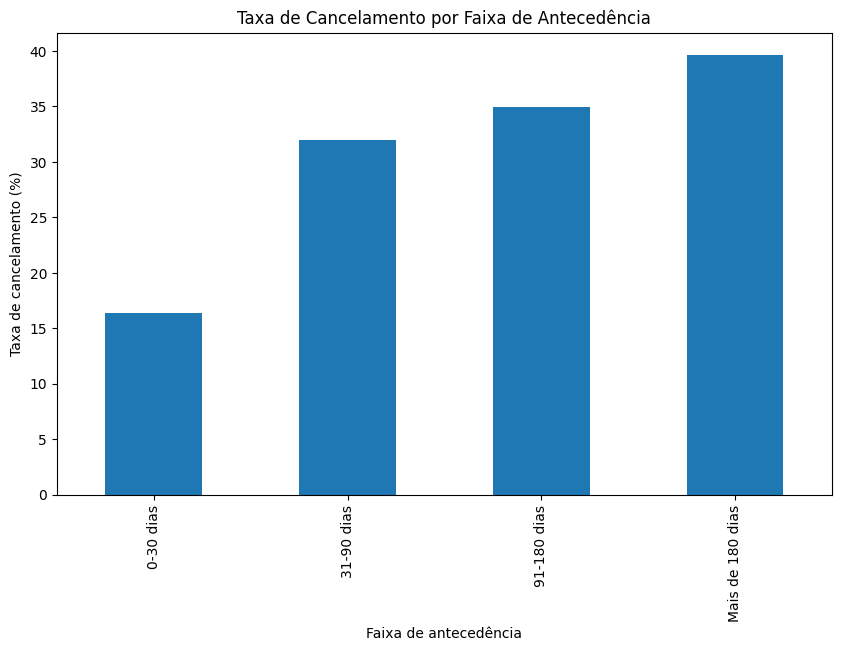

In [233]:
# Gráfico — Taxa de cancelamento por antecedência (lead-time)

taxa_cancelamento_lead = (
    df_tratado.groupby('lead_time_faixa', observed=True)['is_canceled']
    .mean()
    .mul(100)
)

taxa_cancelamento_lead.plot(
    kind='bar',
    figsize=(10, 6),
    title='Taxa de Cancelamento por Faixa de Antecedência',
    xlabel='Faixa de antecedência',
    ylabel='Taxa de cancelamento (%)'
)

### Análise da relação entre antecedência e cancelamento

A análise da taxa de cancelamento por faixa de antecedência mostrou uma tendência crescente.

<p>Reservas realizadas com até 30 dias de antecedência apresentaram taxa de cancelamento de 16,42%, enquanto reservas realizadas com mais de 180 dias apresentaram taxa de 39,68%. As faixas intermediárias apresentaram taxas de 32,01% e 34,98%, respectivamente.

<p>Os resultados indicam que, neste conjunto de dados, reservas realizadas com maior antecedência estão associadas a uma maior ocorrência de cancelamentos.

### Análise da sazonalidade e cancelamentos

O próximo passo da Análise Exploratória será investigar a relação entre o mês de chegada ('arrival_date_month') e o cancelamento das reservas.

<p>A análise permitirá identificar possíveis variações sazonais na taxa de cancelamento ao longo do ano e verificar se determinados períodos apresentam comportamento diferente dos demais

<p>Para preservar a ordem cronológica dos meses, os valores existentes na coluna serão verificados antes do cálculo das taxas e da geração da visualização.

In [234]:
# Verificar os valores existentes na variável/coluna 'arrival_date_month' (mês de chegada).

df_tratado['arrival_date_month'].value_counts()

,count
arrival_date_month,
August,11257
July,10057
May,8355
April,7908
June,7765
March,7512
October,6930
September,6682
February,6098


In [235]:
# Transformar a variável/coluna 'arrival_date_month' em uma categoria ordenada, colocando os meses na ordem cronológica.

meses = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

df_tratado['arrival_date_month'] = pd.Categorical(
    df_tratado['arrival_date_month'],
    categories=meses,
    ordered=True
)

In [236]:
# Calcular a taxa de cancelamento de reservas para cada mês, mantendo a ordem cronológica.

taxa_cancelamento_mes = (
    df_tratado.groupby('arrival_date_month', observed=True)['is_canceled']
    .mean()
    .mul(100)
)

taxa_cancelamento_mes

,is_canceled
arrival_date_month,
January,22.118048
February,23.204329
March,24.361022
April,30.462822
May,29.228007
June,30.315518
July,31.798747
August,32.184419
September,24.453756


### Insight — Sazonalidade e cancelamentos

A análise mensal apresentou variações na taxa de cancelamento ao longo do ano.

<p>A maior taxa foi observada em agosto, com 32,18%, enquanto novembro apresentou a menor taxa, com 21,10%.

<p>As taxas foram mais elevadas principalmente entre abril e agosto e diminuíram a partir de setembro.

<p>Esse comportamento indica uma possível variação sazonal nos cancelamentos das reservas no conjunto de dados analisado, sem implicar relação de causalidade.

<Axes: title={'center': 'Taxa de Cancelamento por Mês de Chegada'}, xlabel='Mês de chegada', ylabel='Taxa de cancelamento (%)'>

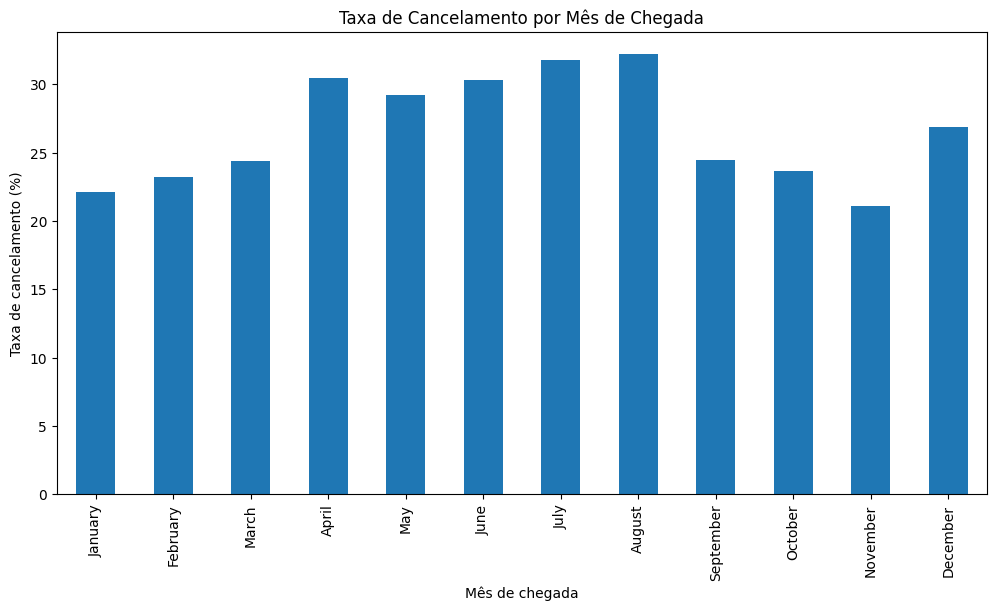

In [237]:
# Gráfico da taxa de cancelamento por mês de chegada (sazonalidade).

taxa_cancelamento_mes.plot(
    kind='bar',
    figsize=(12, 6),
    title='Taxa de Cancelamento por Mês de Chegada',
    xlabel='Mês de chegada',
    ylabel='Taxa de cancelamento (%)'
)

### Análise da evolução das reservas por ano

Para complementar a análise de sazonalidade por mês, será avaliada a taxa de cancelamento por ano de chegada.

<p>Essa análise permite verificar se o comportamento dos cancelamentos apresentou variações ao longo dos anos disponíveis no conjunto de dados, contribuindo para a identificação de possíveis tendências temporais nas reservas.

In [238]:
# Taxa de cancelamento por ano de chegada

cancelamento_por_ano = (
    df_tratado.groupby('arrival_date_year')['is_canceled']
      .mean()
      .mul(100)
      .reset_index(name='taxa_cancelamento')
)

cancelamento_por_ano

,arrival_date_year,taxa_cancelamento
0,2015,20.239080
1,2016,26.439574
2,2017,31.911268


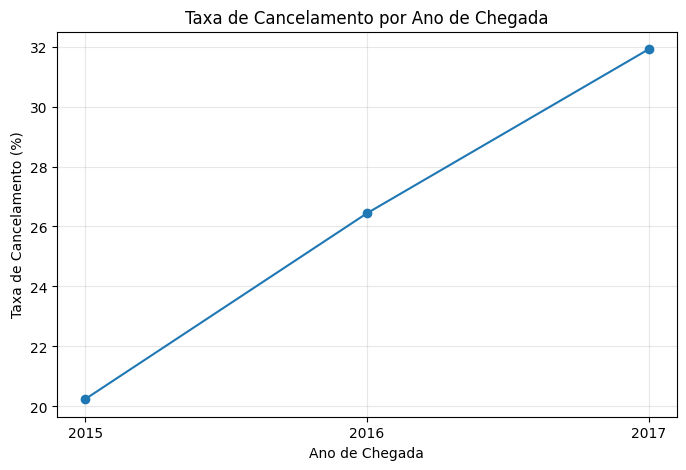

In [239]:
# Gráfico da Taxa de Cancelamento por Ano de Chegada

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    cancelamento_por_ano['arrival_date_year'],
    cancelamento_por_ano['taxa_cancelamento'],
    marker='o'
)

plt.title('Taxa de Cancelamento por Ano de Chegada')
plt.xlabel('Ano de Chegada')
plt.ylabel('Taxa de Cancelamento (%)')
plt.xticks(cancelamento_por_ano['arrival_date_year'])
plt.grid(True, alpha=0.3)

plt.show()

### Insight: tendência de cancelamento ao longo dos anos

A análise da Taxa de Cancelamento por Ano de Chegada indica uma tendência de crescimento dos cancelamentos no período analisado.

<p>A taxa passou de 20,31% em 2015 para 26,44% em 2016, chegando a 31,91% em 2017.

O comportamento demonstra que a proporção de reservas canceladas aumentou ao longo dos anos disponíveis no conjunto de dados, caracterizando uma tendência temporal relevante para a análise do comportamento das reservas.

### Análise da tarifa diária ('adr') x Cancelamentos

Investigar a relação entre a tarifa diária ('adr') e o cancelamento das reservas.

<p>Inicialmente, será analisada a distribuição da variável/coluna 'adr' entre reservas canceladas e não canceladas, buscando identificar diferenças de comportamento e possíveis valores extremos que possam influenciar a análise.

In [241]:
# Comparar relação entre Tarifa Diária ('adr') x Reservas não canceladas (0) e canceladas (1).
# Obter para cada grupo: quantidade de reservas; média da tarifa diária; mediana; menor valor; maior valor.

df_tratado.groupby('is_canceled')['adr'].agg(['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
is_canceled,,,,,
0,63370,102.003671,94.5,0.0,510.0
1,24013,117.831331,109.8,0.0,5400.0


### Investigar a Tarifa Diária ('adr') = 5400

<p><b>Motivo:</b> O valor máximo de 5.400,00 para reservas cancelasdas é muito superior ao restante da distribuição.

<p>É necessário verificar se esse valor extremo representa um registro real ou algum problema nos dados.

In [242]:
# Exibir o registro completo nas principais variáveis relacionadas à reserva, para analisar o contexto do adr = 5400.

df_tratado[df_tratado['adr'] == 5400][
    ['hotel', 'is_canceled', 'lead_time', 'stays_in_weekend_nights',
     'stays_in_week_nights', 'adults', 'children', 'babies',
     'adr', 'reservation_status']
]

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,adr,reservation_status
48515,City Hotel,1,35,0,1,2,0.0,0,5400.0,Canceled


### Tratamento de outlier na variável/coluna 'adr' (Tarifa Diária)

Durante a análise da variável/coluna 'adr', foi identificado um registro com valor de 5.400,00, muito acima dos demais valores observados.

<p>O registro corresponde a uma reserva de uma noite para dois adultos no City Hotel e apresenta status de cancelamento.


<p>Considerando a discrepância extrema desse valor em relação à distribuição da variável e seu potencial de distorcer médias, visualizações e o modelo preditivo, esse registro será removido do DataFrame tratado.

<p>A decisão é específica para esse valor extremo e não implica remoção automática de todos os possíveis outliers identificados pelas regras estatísticas.

In [243]:
# Remover somente o registro com valor = 5400 da variável/coluna 'adr'.

df_tratado = df_tratado[df_tratado['adr'] != 5400]

In [244]:
# Confirmar o tamanho do DataFrame após a exclusão do registro (linha) da coluna 'adr'.

df_tratado.shape

(87382, 32)

In [245]:
# Confirmar que o adr = 5400 realmente não existe mais, mostrando o maior valor existente na coluna 'adr' após a exclusão do valor inconsistente.

df_tratado['adr'].max()

510.0

In [164]:
# Recalcular a relação entre Tarifa Diária ('adr') x Reservas não canceladas (0) e canceladas (1), após exclusão de valor da coluna 'adr' considerado possível anomalia.
# Obter para cada grupo: quantidade de reservas; média da tarifa diária; mediana; menor valor; maior valor.

df_tratado.groupby('is_canceled')['adr'].agg(['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
is_canceled,,,,,
0,63370,102.003671,94.5,0.0,510.0
1,24012,117.611350,109.8,0.0,450.0


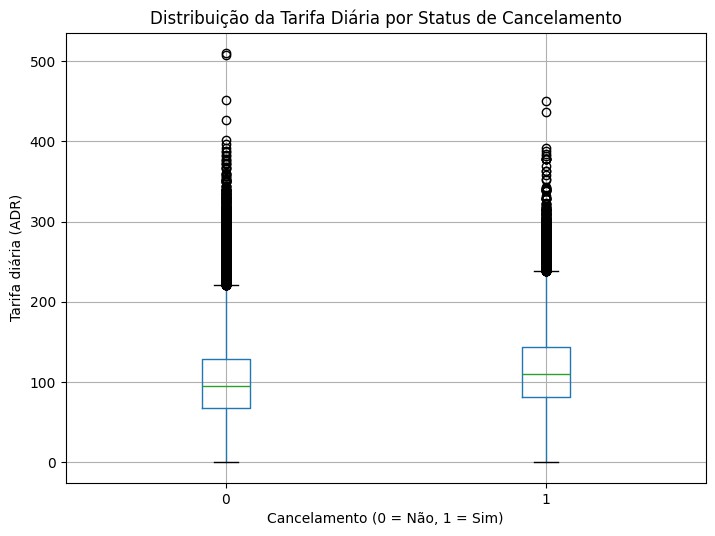

In [246]:
# Gerar Gráfico de ADR × Cancelamento
# Como 'adr' é uma variável numérica contínua, um gráfico de boxplot é mais adequado que um gráfico de barras, pois permite comparar a distribuição das tarifas entre os dois grupos e visualizar a mediana e a dispersão.

df_tratado.boxplot(
    column='adr',
    by='is_canceled',
    figsize=(8, 6)
)

plt.title('Distribuição da Tarifa Diária por Status de Cancelamento')
plt.suptitle('')
plt.xlabel('Cancelamento (0 = Não, 1 = Sim)')
plt.ylabel('Tarifa diária (ADR)')
plt.show()


### Insight — Tarifa Diária e cancelamentos

A comparação da Tarifa Diária ('adr') entre reservas canceladas e não canceladas mostrou diferenças na distribuição dos valores.

<p>As reservas não canceladas apresentaram média de 102,00 e mediana de 94,50, enquanto as reservas canceladas apresentaram média de 117,61 e mediana de 109,80.

<p>Os resultados indicam que, neste conjunto de dados, reservas canceladas estão associadas a tarifas diárias mais elevadas. Essa associação é observada nos dados e não implica causalidade.

### Análise do país de origem ('country') e cancelamentos

Analisar a relação entre o país de origem dos hóspedes ('country') e o comportamento de cancelamento das reservas.

<p>Como essa variável/coluna possui diversos países, inicialmente priorizou-se identificar os países com maior número de reservas no DataFrame tratado.

<p>Em seguida, será comparada a taxa de cancelamento entre os países com maior representatividade, buscando identificar possíveis diferenças no comportamento das reservas.

<p>A análise considerará apenas os dados disponíveis no conjunto analisado e não permitirá estabelecer relações de causalidade.

In [166]:
# Identificar países com maior número de reservas.
# Buscar os 15 países com maior número de reservas.

df_tratado['country'].value_counts().head(15)

,count
country,
PRT,27440
GBR,10432
FRA,8837
ESP,7252
DEU,5387
ITA,3066
IRL,3016
BEL,2081
BRA,1995


In [167]:
# Calcular a taxa de cancelamento de hóspedes dos 15 países com maior número de reservas.

top_15_paises = df_tratado['country'].value_counts().head(15).index

taxa_cancelamento_pais = (
    df_tratado[df_tratado['country'].isin(top_15_paises)]
    .groupby('country')['is_canceled']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

taxa_cancelamento_pais


,is_canceled
country,
BRA,36.441103
PRT,35.634111
ITA,35.061970
ESP,25.675676
USA,24.480000
CHE,24.458599
IRL,22.148541
SWE,21.146953
CN,20.585544


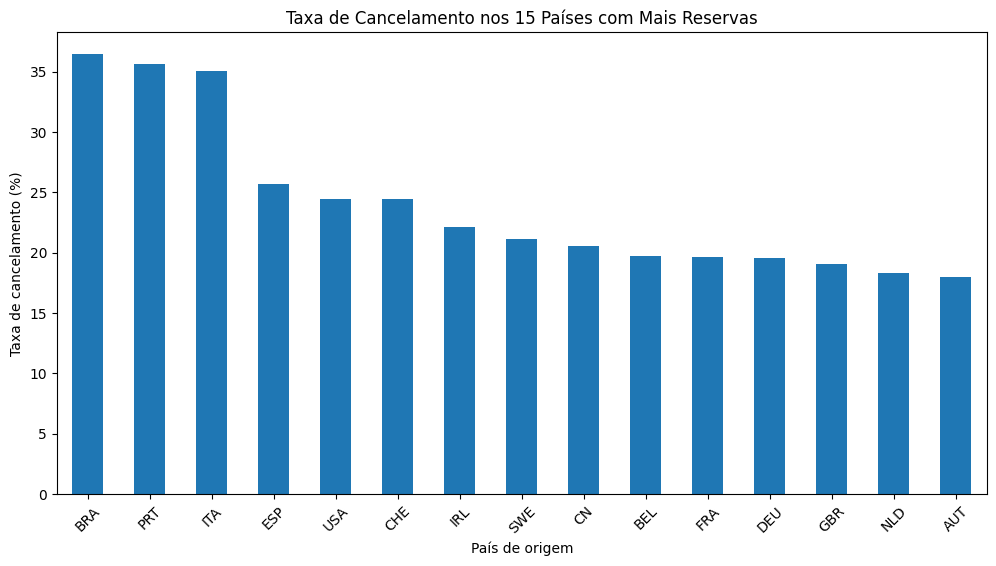

In [168]:
# Gerar Gráfico de Taxa de Cancelamento de Reserva x País de origem ('country').

taxa_cancelamento_pais.plot(
    kind='bar',
    figsize=(12, 6),
    title='Taxa de Cancelamento nos 15 Países com Mais Reservas',
    xlabel='País de origem',
    ylabel='Taxa de cancelamento (%)'
)

plt.xticks(rotation=45)
plt.show()

### Insight — País de Origem ('country') x Cancelamentos

Entre os 15 países com maior número de reservas, foram observadas diferenças nas taxas de cancelamento.

<p>O Brasil apresentou a maior taxa, com 36,44%, seguido por Portugal, com 35,63%, e Itália, com 35,06%.

<p>A menor taxa entre os países analisados foi observada na Áustria, com 17,95%. Esses resultados indicam diferenças no comportamento de cancelamento entre os principais países de origem representados no conjunto de dados.

<p>A análise foi limitada aos 15 países com maior volume de reservas e não permite estabelecer causalidade.

### Verificação final dos dados antes da modelagem

Após as etapas de tratamento e Análise Exploratória de Dados (AED), será realizada uma verificação final da estrutura do DataFrame tratado.

<p>Serão conferidas as quantidades de registros/linhas e colunas, a existência de valores ausentes e os tipos das variáveis.

<p> A etapa garante que o conjunto de dados esteja consistente e preparado para a criação das variáveis utilizadas no modelo preditivo.

In [169]:
# Verificar tamanho atual do DataFrame
df_tratado.shape

(87382, 32)

In [170]:
# Verificar se existem valors ausentes, após os tratamentos feitos no DataFrame tratado.

df_tratado.isnull().sum().sum()

np.int64(0)

In [171]:
# Verificar novamente os tipos de colunas do DataFrame tratado.

df_tratado.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,category
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


### Próxima etapa: Seleção das variáveis para o modelo preditivo

A variável 'is_canceled' será utilizada como variável-alvo (TARGET), conforme definido pela atividade.

<p>As colunas 'reservation_status' e 'reservation_status_date' serão excluídas da modelagem por conterem informações relacionadas ao resultado final da reserva, o que poderia provocar vazamento de dados (data leakage).

<p>A variável derivada 'lead_time_faixa' será mantida para as análises exploratórias, mas não será utilizada como entrada do modelo, pois representa uma transformação de 'lead_time', que será utilizada diretamente como variável preditora.

<p>Dessa forma, o modelo utilizará informações disponíveis sobre a reserva sem utilizar o resultado posterior da reserva como informação de entrada.

In [172]:
# # Definir a variável-alvo (TARGET) = 'is_canceled'
# y será o TARGET: is_canceled e X será formado pelas demais variáveis/colunas selecionadas para servir de entrada.
# Serão excluídas as variáveis/colunas: is_canceled, reservation_status, reservation_status_date e lead_time_faixa.


y = df_tratado['is_canceled']

# Criar as variáveis de entrada, excluindo o TARGET
# e as colunas que não serão utilizadas na modelagem
X = df_tratado.drop(
    columns=[
        'is_canceled',
        'reservation_status',
        'reservation_status_date',
        'lead_time_faixa'
    ]
)

# Verificar a quantidade de linhas e colunas
X.shape, y.shape

((87382, 28), (87382,))

### Codificação das variáveis categóricas

As variáveis categóricas presentes no conjunto de dados precisam ser convertidas para uma representação numérica antes do treinamento do modelo.


<p>Será utilizada a técnica de codificação <b>One-hot encoding</b>, para transformar cada categoria em uma variável binária, permitindo que o algoritmo de classificação processe essas informações sem estabelecer uma ordem artificial entre as categorias.

<p>As variáveis numéricas serão mantidas em seu formato original.

### Separação dos dados em treino e teste

Os dados serão separados em conjuntos de treinamento e teste antes da etapa de codificação das variáveis categóricas.

<p>Será utilizada uma divisão de 80% para treinamento e 20% para teste.

<p>A estratificação pela variável-alvo (TARGET) 'is_canceled' será aplicada para preservar a proporção entre reservas canceladas e não canceladas nos dois conjuntos.

<p>O parâmetro random_state=42 será utilizado para garantir que a divisão possa ser reproduzida.

In [173]:
# Executar a separação treino/teste
# O DataFrame tratado tem 87.382 registros:Treino: aproximadamente 69.905 registros e Teste: aproximadamente 17.477 registros
# As quatro estruturas devem ter a mesma quantidade de linhas correspondente: X_treino → (69905, 28); X_teste  → (17477, 28); y_treino → (69905,) e y_teste  → (17477,)


from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_treino.shape, X_teste.shape, y_treino.shape, y_teste.shape

((69905, 28), (17477, 28), (69905,), (17477,))

### Codificação das variáveis categóricas após a separação dos dados

Após a separação entre treino e teste, as variáveis categóricas serão transformadas por meio de <b>One-Hot Encoding</b>.

<p>O codificador será ajustado exclusivamente com os dados de treinamento e posteriormente aplicado aos conjuntos de treino e teste.

<p>A abordagem evita que informações do conjunto de teste influenciem a preparação dos dados.

<p>A opção <b>handle_unknown='ignore'</b> será utilizada para permitir o processamento de categorias que eventualmente apareçam no conjunto de teste e não estejam presentes no treinamento.

In [250]:
# Conferir colunas categóricas que possuem mais de um tipo de dado
# antes da aplicação do One-Hot Encoding.

colunas_categoricas = X_treino.select_dtypes(
    include=['object', 'category']
).columns

for coluna in colunas_categoricas:
    tipos = X_treino[coluna].map(type).value_counts()
    if len(tipos) > 1:
        print(f'\n{coluna}:')
        print(tipos)

In [251]:
# Necessário transformar toda a coluna/variável 'agent' em texto, preservando os códigos e permitindo que o One-Hot Encoder trate cada agente como uma categoria.
X_treino['agent'] = X_treino['agent'].astype(str)
X_teste['agent'] = X_teste['agent'].astype(str)

In [252]:
# Verificar se todos os registros da coluna/variável 'agent' agora são do tipo texto (string):

X_treino['agent'].map(type).value_counts()

,count
agent,
<class 'str'>,69905


In [255]:
# Reidentificar as colunas após o ajuste da coluna/variável 'agent' para padronizar registros para o tipo texto (string)
# Identificar automaticamente as colunas categóricas e numéricas e usar um ColumnTransformer.
# Aplicar One-Hot Encoding somente às categóricas (One-Hot Encoding: precisa que cada coluna categórica tenha um único tipo de dado.)
# Manter as colunas numéricas como estão.
# fit_transform() será usado somente no treino.
# transform() será usado no teste.
# handle_unknown='ignore' para evitar problemas com categorias novas no teste.


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

colunas_categoricas = X_treino.select_dtypes(
    include=['object', 'category']
).columns

colunas_numericas = X_treino.select_dtypes(
    include=['int64', 'float64']
).columns

# Criar novamente o transformador

preprocessador = ColumnTransformer(
    transformers=[
        ('categoricas', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas),
        ('numericas', 'passthrough', colunas_numericas)
    ]
)

# Ajustar somente com os dados de treino

X_treino_codificado = preprocessador.fit_transform(X_treino)

# Aplicar a mesma transformação aos dados de teste

X_teste_codificado = preprocessador.transform(X_teste)

X_treino_codificado.shape, X_teste_codificado.shape

((69905, 577), (17477, 577))

### Início do treinamento do modelo

Com os dados preparados, separados em conjuntos de treinamento e teste, e com as variáveis categóricas codificadas, será iniciado o treinamento do modelo preditivo.

<p>Nesta etapa, o algoritmo <b>Random Forest</b> será treinado utilizando exclusivamente os dados do conjunto de treinamento (X_treino_codificado e y_treino).

<p>O objetivo é permitir que o modelo aprenda os padrões presentes nas características das reservas e sua relação com a ocorrência de cancelamentos.

<p>O conjunto de teste permanecerá separado e será utilizado posteriormente para avaliar o desempenho do modelo em dados que não foram utilizados durante o treinamento.

<p>

<p>O <b>Random Forest Classifier</b> será utilizado por tratar-se de classificação binária (is_canceled = 0 ou 1),

In [256]:
# Treinamento do modelo de classificação — Random Forest

from sklearn.ensemble import RandomForestClassifier

# Criar o modelo
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Treinar o modelo com os dados de treino
modelo_rf.fit(X_treino_codificado, y_treino)

RandomForestClassifier(n_jobs=-1, random_state=42)

### Início do teste do modelo de classificação — Random Forest

Após o treinamento do modelo Random Forest, será realizada a etapa de teste utilizando o conjunto de dados que foi separado e não participou do treinamento.

<p>O modelo será utilizado para gerar previsões sobre os registros do conjunto de teste, permitindo posteriormente comparar as previsões realizadas com os valores reais da variável-alvo is_canceled.

<p>Essa etapa permitirá avaliar o desempenho do modelo com dados que ele não utilizou durante o aprendizado.

In [257]:
# Primeira etapa de teste do modelo: gerar as previsões usando os dados que ficaram separados para teste.
# O resultado y_pred será a previsão do modelo para cada reserva: 0 → modelo prevê não cancelamento e 1 → modelo prevê cancelamento
# Comparar: y_teste = resultado real  x  y_pred = previsão do modelo

# Fazer previsões no conjunto de teste
y_pred = modelo_rf.predict(X_teste_codificado)

# Verificar as primeiras previsões
y_pred[:10]

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 0])

O resultado: array([0, 1, 0, 0, 1, 0, 0, 0, 0, 0]) confirma que o modelo gerou as previsões corretamente para os primeiros 10 registros do conjunto de teste.

<p>Agora é necessário avaliar se essas previsões estão realmente próximas dos valores reais.
<p>

## Próximo passo — Avaliação do modelo

<p>
### Avaliação do modelo — Acurácia

A acurácia será utilizada inicialmente para medir a proporção de previsões corretas realizadas pelo modelo em relação ao total de observações do conjunto de teste. Essa métrica fornece uma visão geral do desempenho do classificador, comparando os valores previstos pelo modelo com os valores reais de 'is_canceled'.



In [258]:
# Calcular a Acurácia:
# Realizar comparação entre y_teste → valores reais de cancelamento e y_pred → valores previstos pelo Random Forest

from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_teste, y_pred)

print(f'Acurácia do modelo: {acuracia:.4f}')
print(f'Acurácia do modelo: {acuracia * 100:.2f}%')

Acurácia do modelo: 0.8491
Acurácia do modelo: 84.91%


## Resultado: A Acurácia foi de 84,91%.

Significa que, no conjunto de teste, o modelo acertou aproximadamente 84,91% das previsões de cancelamento e não cancelamento.

<p>Mas não é possível concluir ainda que o modelo é bom apenas com essa métrica.

<p>É importante observar um detalhe no nosso problema: os dados estão desbalanceados — cerca de 72,52% são não cancelamentos e 27,48% são cancelamentos. Portanto, faz-se verificar especificamente quantos cancelamentos o modelo conseguiu identificar.

### Avaliação completa do modelo

Após a análise inicial da Acurácia, será realizada uma avaliação mais completa do modelo utilizando diferentes métricas de classificação.

<p>A <b>Matriz de Confusão</b> permitirá analisar a quantidade de previsões corretas e incorretas para cada classe de 'is_canceled'.

<p>Também serão avaliadas a <b>precisão (Precision)</b>, o <b>recall</b> e o <b>F1-score</b>, permitindo verificar não apenas o desempenho geral do modelo, mas também sua capacidade de identificar corretamente as reservas canceladas.

<p>Essas métricas proporcionarão uma avaliação mais detalhada do desempenho do <b>Random Forest</b> no conjunto de teste.

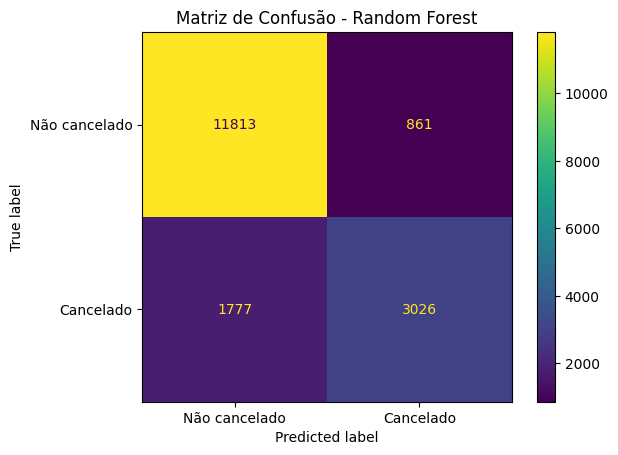

In [259]:
## Calcular Matriz de Confusão: mostra de forma visual onde o modelo acertou e onde errou.

## A matriz terá quatro resultados:
# Verdadeiro Negativo (TN): previu não cancelado e realmente não foi cancelado..
# Falso Positivo (FP): previu cancelado, mas não foi cancelado.
# Falso Negativo (FN): previu não cancelado, mas foi cancelado.
# Verdadeiro Positivo (TP): previu cancelado e realmente foi cancelado.


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calcular a matriz de confusão
cm = confusion_matrix(y_teste, y_pred)

# Exibir a matriz de confusão
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Não cancelado', 'Cancelado']
)

disp.plot()
plt.title('Matriz de Confusão - Random Forest')
plt.show()

### Resultado:


<b>• 11.813 — Verdadeiros Negativos (TN):</b> o modelo previu não cancelado e realmente não foi cancelado.

<b><p> • 861 — Falsos Positivos (FP):</b> o modelo previu cancelamento, mas a reserva não foi cancelada.


<b><p> • 1.777 — Falsos Negativos (FN):</b> o modelo previu não cancelamento, mas a reserva foi cancelada.


<b><p> • 3.026 — Verdadeiros Positivos (TP):</b> o modelo previu cancelamento e realmente foi cancelado.

<p>

<p><b>Importante</b>

Dos 4.803 cancelamentos reais no conjunto de teste:

3.026 foram identificados corretamente pelo modelo, enquanto 1.777 não foram identificados.

In [260]:
## Calcular Precision, Recall e F1-score para cada classe, além de mostrar a quantidade de exemplos de cada classe.
# Precision (Precisão): entre as reservas que o modelo classificou como canceladas, quantas realmente foram canceladas.
# Recall: entre as reservas que realmente foram canceladas, quantas o modelo conseguiu identificar.
# F1-score: combina Precision e Recall em uma única métrica.
# Support: quantidade real de registros de cada classe no conjunto de teste.

# Os resultados separadamente para: Classe 0 — Não cancelado  e  Classe 1 — Cancelado



from sklearn.metrics import classification_report

print(classification_report(
    y_teste,
    y_pred,
    target_names=['Não cancelado', 'Cancelado']
))

               precision    recall  f1-score   support

Não cancelado       0.87      0.93      0.90     12674
    Cancelado       0.78      0.63      0.70      4803

     accuracy                           0.85     17477
    macro avg       0.82      0.78      0.80     17477
 weighted avg       0.84      0.85      0.84     17477



### Resultados

<b>Não cancelado (classe 0)</b>

<p><b>• Precision:</b> 0,87 → quando o modelo prevê “não cancelado”, acerta em 87% dos casos.


<p><b>• Recall:</b> 0,93 → identifica corretamente 93% das reservas que realmente não foram canceladas.

<p><b>• F1-score:</b> 0,90 → bom equilíbrio entre precisão e recall.



<p><b>Cancelado (classe 1)</b>

<p><b>• Precision:</b> 0,78 → entre as reservas que o modelo classificou como canceladas, 78% realmente foram canceladas.


<p><b>• Recall:</b> 0,63 → o modelo conseguiu identificar 63% dos cancelamentos reais.


<p><b>• F1-score:</b> 0,70 → desempenho moderado para a identificação da classe cancelada.


<p><b>IMPORTANTE</b>

<p>O Recall de 63% para cancelamentos merece atenção. Significa que, dos 4.803 cancelamentos reais existentes no conjunto de teste, o modelo identificou corretamente 3.026, mas deixou de identificar 1.777.

<p>O valor corresponde exatamente com nossa a Matriz de Confusão:  FN = 1.777


<p>Pode-se constatar que o modelo apresenta bom desempenho geral, com 84,91% de acurácia, mas tem maior dificuldade para identificar reservas canceladas do que reservas não canceladas.

## Conclusões

###Breve análise dos resultados do modelo preditivo


<p>• O modelo alcançou 84,91% de acurácia;

<p>• Apresentou 78% de Precision para a classe cancelada;

<p>• Apresentou 63% de Recall para a classe cancelada;

<p>• Apresentou F1-score de 70% para a classe cancelada;


<p> Portanto, apresenta desempenho geral satisfatório, mas possui maior dificuldade em identificar todos os cancelamentos reais.
